# Pretrained Audio Models — Frozen Embeddings (AST, MERT, CLAP)

Modern pretrained audio model stage: extract frozen embeddings, then train classifiers.

**Models:** AST, MERT-v1-95M, CLAP-HTSAT (configurable in `configs/features.yaml`)  
**Default:** no fine-tuning of large pretrained backbones.  
**Offline weights:** set `features.pretrained.allow_download: false` after caching locally.

In [14]:
from pathlib import Path
import importlib
import logging
import sys

import pandas as pd
from IPython.display import display

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    datefmt="%H:%M:%S",
)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "configs").exists() and (PROJECT_ROOT.parent / "configs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.features.pretrained_audio_embeddings as pretrained_audio_embeddings
import src.training.train_pretrained_embeddings as train_pretrained_embeddings

importlib.reload(pretrained_audio_embeddings)
importlib.reload(train_pretrained_embeddings)

from src.utils.config import get_project_root, load_configs, resolve_path
from src.features.pretrained_audio_embeddings import (
    check_pretrained_dependencies,
    extract_all_pretrained_embeddings,
    extract_pretrained_embeddings_for_model,
    load_pretrained_embeddings_index,
    resolve_pretrained_model_configs,
)
from src.training.train_pretrained_embeddings import train_all_pretrained_embedding_classifiers

configs = load_configs(PROJECT_ROOT)
root = get_project_root(PROJECT_ROOT)
model_configs = resolve_pretrained_model_configs(configs)

## 1. Check dependencies

In [15]:
status = check_pretrained_dependencies(configs)
print(status)

print("\nConfigured pretrained models:")
for model_cfg in model_configs:
    print(
        f"- {model_cfg['alias']}: {model_cfg['model_name']} "
        f"({model_cfg['backend']}, sr={model_cfg['sample_rate']})"
    )

if not status["available"]:
    print("\nPretrained experiments will be skipped.")
    print("To enable: install dependencies and place model weights locally,")
    print("or set features.pretrained.allow_download=true in configs/features.yaml")

{'available': True, 'provider': 'huggingface', 'models': [{'alias': 'ast_audioset', 'model_name': 'MIT/ast-finetuned-audioset-10-10-0.4593', 'backend': 'hf_automodel', 'sample_rate': 16000, 'max_duration_sec': 30.0, 'pooling': 'auto', 'trust_remote_code': False}, {'alias': 'mert_v1_95m', 'model_name': 'm-a-p/MERT-v1-95M', 'backend': 'mert_hf', 'sample_rate': 24000, 'max_duration_sec': 30.0, 'pooling': 'hidden_states_time_mean_last_layer', 'trust_remote_code': True}, {'alias': 'clap_htsat_unfused', 'model_name': 'laion/clap-htsat-unfused', 'backend': 'clap_hf', 'sample_rate': 48000, 'max_duration_sec': 30.0, 'pooling': 'get_audio_features', 'trust_remote_code': False}], 'model_name': 'MIT/ast-finetuned-audioset-10-10-0.4593', 'message': 'Hugging Face transformers is available (3 model(s) configured).'}

Configured pretrained models:
- ast_audioset: MIT/ast-finetuned-audioset-10-10-0.4593 (hf_automodel, sr=16000)
- mert_v1_95m: m-a-p/MERT-v1-95M (mert_hf, sr=24000)
- clap_htsat_unfused: 

## 2. Extract or load embeddings

In [16]:
if not status["available"]:
    index_df = None
    print("Skipping embedding extraction — dependencies unavailable.")
else:
    index_df = extract_all_pretrained_embeddings(configs, force=False)
    if index_df.empty:
        print("No embeddings extracted.")
        index_df = None
    else:
        print(
            f"Embedding indexes: {index_df['model_alias'].nunique()} model(s), "
            f"{len(index_df)} total rows"
        )
        display(
            index_df.groupby(["model_alias", "backend", "embedding_dim"], as_index=False)
            .size()
            .rename(columns={"size": "tracks"})
        )
        index_df.head()

08:49:12 | INFO | src.data.load_deam | Found dynamic annotation folder: C:\Users\athen\Desktop\music-emotion-recognition\data\raw\DEAM\DEAM_annotations\annotations\annotations_averaged_per_song\dynamic (per second annotations)
08:49:12 | INFO | src.data.load_deam | Found dynamic annotation folder: C:\Users\athen\Desktop\music-emotion-recognition\data\raw\DEAM\DEAM_annotations\annotations\annotations_averaged_per_song\dynamic (per second annotations)
08:49:12 | INFO | src.data.load_deam | Loaded static annotations from static_annotations_averaged_songs_1_2000.csv (1744 rows)
08:49:12 | INFO | src.data.load_deam | Loaded static annotations from static_annotations_averaged_songs_2000_2058.csv (58 rows)
08:49:12 | INFO | src.data.load_deam | Found dynamic annotation folder: C:\Users\athen\Desktop\music-emotion-recognition\data\raw\DEAM\DEAM_annotations\annotations\annotations_averaged_per_song\dynamic (per second annotations)
08:49:12 | INFO | src.data.load_deam | Dynamic annotation folder

Scanning audio files:   0%|          | 0/1802 [00:00<?, ?it/s]

08:49:23 | INFO | src.features.pretrained_audio_embeddings | Reusing legacy embedding index for alias=ast_audioset (1802 tracks) from C:\Users\athen\Desktop\music-emotion-recognition\data\features\pretrained_embeddings_index.csv
08:49:23 | INFO | src.features.pretrained_audio_embeddings | Reusing cached embeddings for alias=mert_v1_95m (1802 tracks) from C:\Users\athen\Desktop\music-emotion-recognition\data\features\pretrained_embeddings\mert_v1_95m\index.csv
08:49:23 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/laion/clap-htsat-unfused/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
08:49:23 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/laion/clap-htsat-unfused/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
08:49:23 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/laion/clap-htsat-unfused/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
08:49:24 | INFO | httpx | HTTP Request: 

Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

08:49:27 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/laion/clap-htsat-unfused/commits/main "HTTP/1.1 200 OK"
08:49:27 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/laion/clap-htsat-unfused/discussions?p=0 "HTTP/1.1 200 OK"
08:49:27 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/laion/clap-htsat-unfused/commits/refs%2Fpr%2F3 "HTTP/1.1 200 OK"
08:49:27 | INFO | src.features.pretrained_audio_embeddings | Extracting embeddings | alias=clap_htsat_unfused | model=laion/clap-htsat-unfused | backend=clap_hf | sample_rate=48000 | max_duration=30.0s | device=cuda


Embeddings [clap_htsat_unfused]:   0%|          | 0/1802 [00:00<?, ?it/s]

08:49:27 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/laion/clap-htsat-unfused/resolve/refs%2Fpr%2F3/model.safetensors.index.json "HTTP/1.1 404 Not Found"
08:49:27 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/laion/clap-htsat-unfused/resolve/refs%2Fpr%2F3/model.safetensors "HTTP/1.1 302 Found"
08:54:52 | INFO | src.features.pretrained_audio_embeddings | Saved embeddings for alias=clap_htsat_unfused | tracks=1802 | skipped=0 | embedding_dim=512 | index=C:\Users\athen\Desktop\music-emotion-recognition\data\features\pretrained_embeddings\clap_htsat_unfused\index.csv
08:54:52 | INFO | src.features.pretrained_audio_embeddings | Combined pretrained embedding index: 5406 rows across 3 model(s).


Embedding indexes: 3 model(s), 5406 total rows


,model_alias,backend,embedding_dim,tracks
0,ast_audioset,hf_automodel,768,1802
1,clap_htsat_unfused,clap_hf,512,1802
2,mert_v1_95m,mert_hf,768,1802


## 3. Train classifiers on embeddings

In [17]:
if not status["available"]:
    summary_df = None
    print("Skipping classifier training — dependencies unavailable.")
else:
    summary_df = train_all_pretrained_embedding_classifiers(
        configs=configs,
        extract_embeddings=False,
        force_extract=False,
    )
    summary_df

08:56:39 | INFO | src.training.train_pretrained_embeddings | Training classifiers | alias=ast_audioset | backend=hf_automodel | shape=(1802, 768) | train=1261 val=270 test=271 | embedding_dim=768


Classifiers [ast_audioset]:   0%|          | 0/4 [00:00<?, ?it/s]

08:56:39 | INFO | src.training.train_pretrained_embeddings | Training classifier alias=ast_audioset classifier=logistic_regression
c:\Users\athen\miniconda3\envs\music-emotion-recognition\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
08:56:39 | INFO | src.training.train_pretrained_embeddings | ast_audioset / logistic_regression [val] — accuracy=0.5704, macro_f1=0.4847, weighted_f1=0.5766
08:56:39 | INFO | src.training.train_pretrained_embeddings | ast_audioset / logistic_regression [test] — accuracy=0.6273, macro_f1=0.5417, weighted_f1=0.6254
08:56:39 | INFO | src.training.train_pretrained_embeddings | Training classifier alias=ast_audioset classifier=random_forest
08:56:48 | INFO | src.training.train_pretrained_embeddings | ast_audioset / random_forest [val] — accuracy=0.

Classifiers [mert_v1_95m]:   0%|          | 0/4 [00:00<?, ?it/s]

09:03:19 | INFO | src.training.train_pretrained_embeddings | Training classifier alias=mert_v1_95m classifier=logistic_regression
c:\Users\athen\miniconda3\envs\music-emotion-recognition\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
09:03:19 | INFO | src.training.train_pretrained_embeddings | mert_v1_95m / logistic_regression [val] — accuracy=0.5296, macro_f1=0.4304, weighted_f1=0.5313
09:03:19 | INFO | src.training.train_pretrained_embeddings | mert_v1_95m / logistic_regression [test] — accuracy=0.5720, macro_f1=0.4467, weighted_f1=0.5732
09:03:19 | INFO | src.training.train_pretrained_embeddings | Training classifier alias=mert_v1_95m classifier=random_forest
09:03:27 | INFO | src.training.train_pretrained_embeddings | mert_v1_95m / random_forest [val] — accuracy=0.6407,

Classifiers [clap_htsat_unfused]:   0%|          | 0/4 [00:00<?, ?it/s]

09:09:46 | INFO | src.training.train_pretrained_embeddings | Training classifier alias=clap_htsat_unfused classifier=logistic_regression
c:\Users\athen\miniconda3\envs\music-emotion-recognition\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
09:09:46 | INFO | src.training.train_pretrained_embeddings | clap_htsat_unfused / logistic_regression [val] — accuracy=0.5815, macro_f1=0.4847, weighted_f1=0.5850
09:09:46 | INFO | src.training.train_pretrained_embeddings | clap_htsat_unfused / logistic_regression [test] — accuracy=0.5867, macro_f1=0.4708, weighted_f1=0.5781
09:09:46 | INFO | src.training.train_pretrained_embeddings | Training classifier alias=clap_htsat_unfused classifier=random_forest
09:09:54 | INFO | src.training.train_pretrained_embeddings | clap_htsat_unfused / ran

In [18]:
if summary_df is not None and not summary_df.empty:
    test_df = summary_df[summary_df["eval_split"] == "test"].copy()

    print("Test results sorted by macro F1:")
    display(
        test_df.sort_values("macro_f1", ascending=False)[
            ["model_alias", "model_name", "classifier", "macro_f1", "accuracy", "weighted_f1"]
        ]
    )

    print("\nTest results sorted by accuracy:")
    display(
        test_df.sort_values("accuracy", ascending=False)[
            ["model_alias", "model_name", "classifier", "accuracy", "macro_f1", "weighted_f1"]
        ]
    )

Test results sorted by macro F1:


,model_alias,model_name,classifier,macro_f1,accuracy,weighted_f1
1,ast_audioset,MIT/ast-finetuned-audioset-10-10-0.4593,logistic_regression,0.541733,0.627306,0.625412
7,ast_audioset,MIT/ast-finetuned-audioset-10-10-0.4593,xgboost,0.538109,0.708487,0.656434
5,ast_audioset,MIT/ast-finetuned-audioset-10-10-0.4593,gradient_boosting,0.492451,0.675277,0.623150
23,clap_htsat_unfused,laion/clap-htsat-unfused,xgboost,0.479341,0.667897,0.615731
17,clap_htsat_unfused,laion/clap-htsat-unfused,logistic_regression,0.470764,0.586716,0.578115
9,mert_v1_95m,m-a-p/MERT-v1-95M,logistic_regression,0.446662,0.571956,0.573177
21,clap_htsat_unfused,laion/clap-htsat-unfused,gradient_boosting,0.444027,0.634686,0.588929
19,clap_htsat_unfused,laion/clap-htsat-unfused,random_forest,0.417533,0.664207,0.577687
13,mert_v1_95m,m-a-p/MERT-v1-95M,gradient_boosting,0.392660,0.616236,0.545503
3,ast_audioset,MIT/ast-finetuned-audioset-10-10-0.4593,random_forest,0.379929,0.656827,0.554888



Test results sorted by accuracy:


,model_alias,model_name,classifier,accuracy,macro_f1,weighted_f1
7,ast_audioset,MIT/ast-finetuned-audioset-10-10-0.4593,xgboost,0.708487,0.538109,0.656434
5,ast_audioset,MIT/ast-finetuned-audioset-10-10-0.4593,gradient_boosting,0.675277,0.492451,0.623150
23,clap_htsat_unfused,laion/clap-htsat-unfused,xgboost,0.667897,0.479341,0.615731
19,clap_htsat_unfused,laion/clap-htsat-unfused,random_forest,0.664207,0.417533,0.577687
3,ast_audioset,MIT/ast-finetuned-audioset-10-10-0.4593,random_forest,0.656827,0.379929,0.554888
21,clap_htsat_unfused,laion/clap-htsat-unfused,gradient_boosting,0.634686,0.444027,0.588929
1,ast_audioset,MIT/ast-finetuned-audioset-10-10-0.4593,logistic_regression,0.627306,0.541733,0.625412
13,mert_v1_95m,m-a-p/MERT-v1-95M,gradient_boosting,0.616236,0.392660,0.545503
15,mert_v1_95m,m-a-p/MERT-v1-95M,xgboost,0.608856,0.368056,0.525734
11,mert_v1_95m,m-a-p/MERT-v1-95M,random_forest,0.605166,0.351724,0.513616


In [19]:
summary_df

,model_name,task_type,feature_type,target_type,eval_split,pretrained_model,classifier,train_size,val_size,test_size,accuracy,macro_f1,weighted_f1
0,MIT__ast-finetuned-audioset-10-10-0.4593_logis...,pretrained_embedding,pretrained_audio_embedding,emotion_quadrant,val,MIT/ast-finetuned-audioset-10-10-0.4593,logistic_regression,1261,270,271,0.570370,0.484694,0.576636
1,MIT__ast-finetuned-audioset-10-10-0.4593_logis...,pretrained_embedding,pretrained_audio_embedding,emotion_quadrant,test,MIT/ast-finetuned-audioset-10-10-0.4593,logistic_regression,1261,270,271,0.627306,0.541733,0.625412
2,MIT__ast-finetuned-audioset-10-10-0.4593_rando...,pretrained_embedding,pretrained_audio_embedding,emotion_quadrant,val,MIT/ast-finetuned-audioset-10-10-0.4593,random_forest,1261,270,271,0.644444,0.371791,0.545299
3,MIT__ast-finetuned-audioset-10-10-0.4593_rando...,pretrained_embedding,pretrained_audio_embedding,emotion_quadrant,test,MIT/ast-finetuned-audioset-10-10-0.4593,random_forest,1261,270,271,0.656827,0.379929,0.554888
4,MIT__ast-finetuned-audioset-10-10-0.4593_gradi...,pretrained_embedding,pretrained_audio_embedding,emotion_quadrant,val,MIT/ast-finetuned-audioset-10-10-0.4593,gradient_boosting,1261,270,271,0.644444,0.475672,0.604525
5,MIT__ast-finetuned-audioset-10-10-0.4593_gradi...,pretrained_embedding,pretrained_audio_embedding,emotion_quadrant,test,MIT/ast-finetuned-audioset-10-10-0.4593,gradient_boosting,1261,270,271,0.675277,0.492451,0.623150
6,MIT__ast-finetuned-audioset-10-10-0.4593_xgboost,pretrained_embedding,pretrained_audio_embedding,emotion_quadrant,val,MIT/ast-finetuned-audioset-10-10-0.4593,xgboost,1261,270,271,0.655556,0.464954,0.599133
7,MIT__ast-finetuned-audioset-10-10-0.4593_xgboost,pretrained_embedding,pretrained_audio_embedding,emotion_quadrant,test,MIT/ast-finetuned-audioset-10-10-0.4593,xgboost,1261,270,271,0.708487,0.538109,0.656434


## 4. Compare pretrained models (test macro F1)

C:\Users\athen\AppData\Local\Temp\ipykernel_22276\4154817455.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha="right")


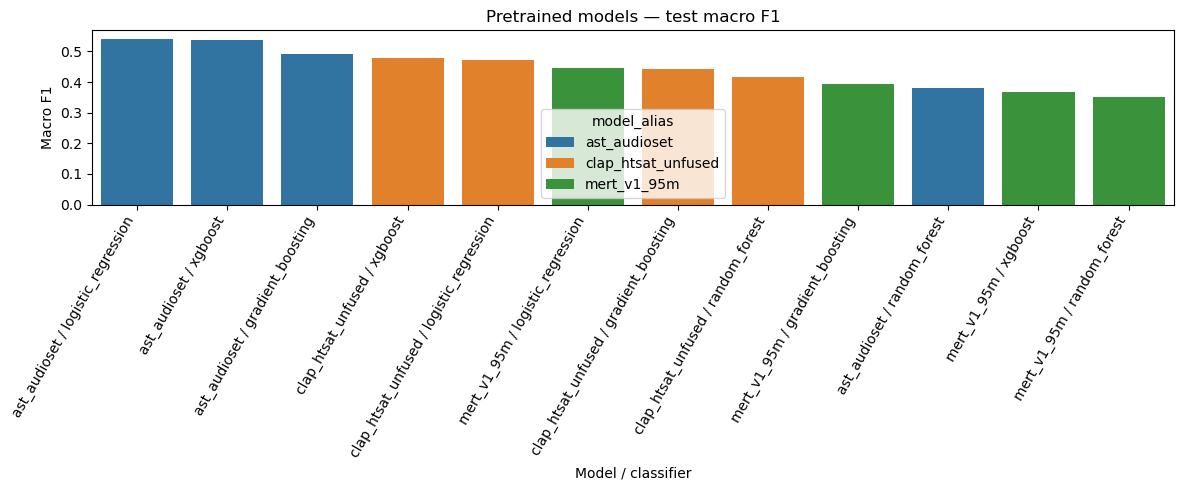

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

if summary_df is not None and not summary_df.empty:
    plot_df = (
        summary_df[summary_df["eval_split"] == "test"]
        .sort_values("macro_f1", ascending=False)
        .copy()
    )
    plot_df["label"] = plot_df["model_alias"] + " / " + plot_df["classifier"]

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=plot_df, x="label", y="macro_f1", hue="model_alias", ax=ax, dodge=False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha="right")
    ax.set_title("Pretrained models — test macro F1")
    ax.set_xlabel("Model / classifier")
    ax.set_ylabel("Macro F1")
    fig.tight_layout()
    plt.show()
else:
    print("No summary available for plotting.")